# 04 — Model 1: Interaction Logit + AME

Causal model with heterogeneous treatment effect using:
`has_booster * internet_usage`

## What This Approach Does (Concept + Math)

Goal: estimate the causal effect of booster adoption on cancellation probability while allowing the effect to vary by internet-usage tier.

Let:
- $Y_i \in \{0,1\}$ be cancellation
- $T_i \in \{0,1\}$ be booster adoption
- $G_i$ be internet-usage tier
- $X_i$ be control covariates (age, tenure, TV/mobile products, commune)

We fit an interaction logistic model:
$$
\Pr(Y_i=1\mid T_i,G_i,X_i) = \Lambda\left(\beta_0 + \beta_T T_i + \beta_G^\top G_i + \beta_{TG}^\top(T_i\cdot G_i) + \gamma^\top X_i\right),
\quad \Lambda(z)=\frac{1}{1+e^{-z}}
$$

Why interaction matters: $\beta_{TG}$ allows booster impact to differ across tiers instead of forcing one common treatment effect.

Potential-outcome view at unit level:
$$
\widehat{\tau}_i = \hat p_i(1)-\hat p_i(0)
$$
where $\hat p_i(1)$ is predicted cancellation with $T_i=1$ and $\hat p_i(0)$ with $T_i=0$, holding all other features fixed for the same user.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Runtime controls
BOOTSTRAP_ITERATIONS = 200

from tqdm.notebook import tqdm

try:
    from helpers import load_analysis_data, prepare_model_data
    from config import AME_PLOT_COLORS, SNS_STYLE, SNS_PALETTE, MATPLOTLIB_THEME
except ModuleNotFoundError:
    import sys
    from pathlib import Path
    sys.path.append(str((Path.cwd() / "notebooks").resolve()))
    from helpers import load_analysis_data, prepare_model_data
    from config import AME_PLOT_COLORS, SNS_STYLE, SNS_PALETTE, MATPLOTLIB_THEME

pd.set_option("display.max_columns", 200)
sns.set_theme(style=SNS_STYLE, palette=SNS_PALETTE)
plt.rcParams.update(MATPLOTLIB_THEME)

df = load_analysis_data()
df_clean = prepare_model_data(df)
print(f"Rows for model: {len(df_clean):,}")
print(f"Bootstrap iterations: {BOOTSTRAP_ITERATIONS}")

Rows for model: 125,000
Bootstrap iterations: 200


In [2]:
formula_interaction = (
    "churned ~ has_booster * C(internet_usage) + age + tenure + "
    "C(tv_product) + C(mobile_product) + C(commune)"
)
logit_interaction = smf.logit(formula=formula_interaction, data=df_clean).fit(disp=False)
print(logit_interaction.summary())

                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:               125000
Model:                          Logit   Df Residuals:                   124983
Method:                           MLE   Df Model:                           16
Date:                Fri, 19 Jun 2026   Pseudo R-squ.:                 0.01244
Time:                        08:59:43   Log-Likelihood:                -50271.
converged:                       True   LL-Null:                       -50905.
Covariance Type:            nonrobust   LLR p-value:                8.079e-260
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                   -1.9277      0.041    -46.603      0.000      -2.009      -1.847
C(internet_usage)[T.Medium]              

## AME, Heterogeneity, and Uncertainty

### Average Marginal Effect (AME)

Overall AME is the sample average of unit-level effects:
$$
\widehat{AME}=\frac{1}{n}\sum_{i=1}^{n}\left(\hat p_i(1)-\hat p_i(0)\right).
$$

Tier-specific AME (for tier $g$):
$$
\widehat{AME}_g=\frac{1}{n_g}\sum_{i:G_i=g}\left(\hat p_i(1)-\hat p_i(0)\right).
$$

### How confidence intervals are estimated

The notebook reports two CI types for the treatment effect:

1. Delta-method CI (analytic, fast)
- Treat the AME as a smooth function of logit coefficients, $\hat\theta=f(\hat\beta)$.
- Use first-order Taylor approximation around $\hat\beta$:
$$
\mathrm{Var}(\hat\theta)\approx \nabla f(\hat\beta)^\top\,\mathrm{Var}(\hat\beta)\,\nabla f(\hat\beta).
$$
- Compute $SE(\hat\theta)=\sqrt{\mathrm{Var}(\hat\theta)}$ and 95% CI:
$$
\hat\theta \pm 1.96\,SE(\hat\theta).
$$

2. Bootstrap CI (resampling, robust to nonlinearity)
- Resample rows with replacement $B$ times (here $B=200$).
- For each bootstrap sample $b$: refit logit model, recompute $\widehat{AME}^{(b)}$.
- Use percentile CI from empirical distribution:
$$
\left[Q_{0.025}(\widehat{AME}^{(b)}),\;Q_{0.975}(\widehat{AME}^{(b)})\right].
$$

Optional bootstrap standard error (for diagnostics):
$$
\widehat{SE}_{boot}=\sqrt{\frac{1}{B-1}\sum_{b=1}^{B}\left(\widehat{AME}^{(b)}-\overline{\widehat{AME}}\right)^2}.
$$

### Why we estimate CI this way

- AME is a nonlinear transformation of model coefficients, so uncertainty must be propagated from $\hat\beta$ to $\widehat{AME}$.
- Delta method provides a quick closed-form approximation when asymptotic normality is reasonable.
- Bootstrap checks the same uncertainty with fewer shape assumptions and better captures finite-sample irregularities.
- Reporting both improves credibility: agreement suggests stable inference; divergence signals model or sample sensitivity.

Interpretation: if AME is negative, booster lowers churn probability (in percentage points after multiplying by 100).

In [3]:
def compute_effects_from_model(fitted_model, frame):
    f1 = frame.copy(); f0 = frame.copy()
    f1["has_booster"] = 1; f0["has_booster"] = 0
    ite = fitted_model.predict(f1) - fitted_model.predict(f0)
    temp = frame.assign(ite_churn=ite)
    overall = float(temp["ite_churn"].mean())
    by_tier = temp.groupby("internet_usage", observed=True)["ite_churn"].mean()
    return overall, by_tier, temp

def delta_method_ame(fitted_model, df_subset):
    f1 = df_subset.copy(); f0 = df_subset.copy()
    f1["has_booster"] = 1; f0["has_booster"] = 0
    p1 = fitted_model.predict(f1).to_numpy()
    p0 = fitted_model.predict(f0).to_numpy()
    ame = float(np.mean(p1 - p0))
    exog1, _ = fitted_model._transform_predict_exog(f1)
    exog0, _ = fitted_model._transform_predict_exog(f0)
    exog1 = np.asarray(exog1, dtype=float)
    exog0 = np.asarray(exog0, dtype=float)
    grad = np.mean((p1 * (1 - p1))[:, None] * exog1 - (p0 * (1 - p0))[:, None] * exog0, axis=0)
    var_ame = float(grad @ fitted_model.cov_params() @ grad)
    se = np.sqrt(max(var_ame, 0.0))
    return ame, ame - 1.96 * se, ame + 1.96 * se

In [9]:
ame_overall, _, temp = compute_effects_from_model(logit_interaction, df_clean)
tier_effects = temp.groupby("internet_usage", observed=True)["ite_churn"].agg(mean="mean", count="count")

# Overall delta CI from get_margeff
mfx = logit_interaction.get_margeff(at="overall", method="dydx")
mfx_row = mfx.summary_frame().loc["has_booster"]
dm_low = float(mfx_row["Conf. Int. Low"])
dm_high = float(mfx_row["Cont. Int. Hi."])

# Tier-level delta CIs
tier_dm = {}
for t in tier_effects.index:
    sub = df_clean[df_clean["internet_usage"].astype(str) == str(t)].copy()
    _, lo, hi = delta_method_ame(logit_interaction, sub)
    tier_dm[str(t)] = (lo, hi)
tier_effects["ci_low_delta"] = [tier_dm[str(t)][0] for t in tier_effects.index]
tier_effects["ci_high_delta"] = [tier_dm[str(t)][1] for t in tier_effects.index]

# Bootstrap CIs
B = BOOTSTRAP_ITERATIONS
rng = np.random.default_rng(42)
boot_overall = []
boot_by_tier = []
for _ in tqdm(range(B), total=B, desc="Bootstrap", dynamic_ncols=True, leave=True):
    idx = rng.integers(0, len(df_clean), len(df_clean))
    bdf = df_clean.iloc[idx].copy()
    try:
        bfit = smf.logit(formula=formula_interaction, data=bdf).fit(disp=False)
        b_overall, b_tier, _ = compute_effects_from_model(bfit, bdf)
        boot_overall.append(b_overall)
        boot_by_tier.append(b_tier.reindex(tier_effects.index))
    except Exception:
        continue

if len(boot_overall) == 0:
    raise RuntimeError("All bootstrap fits failed; no CI can be computed.")

boot_overall = np.array(boot_overall)
boot_tier = pd.DataFrame(boot_by_tier)
bs_low, bs_high = np.quantile(boot_overall, [0.025, 0.975])
tier_effects["ci_low_boot"] = boot_tier.quantile(0.025).values
tier_effects["ci_high_boot"] = boot_tier.quantile(0.975).values

print(f"Overall AME: {ame_overall*100:+.2f} pp")
print(f"Overall Delta 95% CI: [{dm_low*100:+.2f}, {dm_high*100:+.2f}] pp")
print(f"Overall Bootstrap 95% CI: [{bs_low*100:+.2f}, {bs_high*100:+.2f}] pp")

result_table = tier_effects.reset_index().assign(
    booster_effect_pp=lambda d: d["mean"] * 100,
    ci_low_delta_pp=lambda d: d["ci_low_delta"] * 100,
    ci_high_delta_pp=lambda d: d["ci_high_delta"] * 100,
    ci_low_boot_pp=lambda d: d["ci_low_boot"] * 100,
    ci_high_boot_pp=lambda d: d["ci_high_boot"] * 100,
)
raw_population_pct = result_table["count"] / len(df_clean) * 100
rounded_population_pct = np.floor(raw_population_pct + 0.5).astype(int)
rounding_gap = int(100 - rounded_population_pct.sum())
if rounding_gap != 0:
    fractional = raw_population_pct - np.floor(raw_population_pct)
    order = np.argsort(-fractional.to_numpy()) if rounding_gap > 0 else np.argsort(fractional.to_numpy())
    for idx in order[:abs(rounding_gap)]:
        rounded_population_pct.iloc[idx] += 1 if rounding_gap > 0 else -1
result_table["population_pct"] = rounded_population_pct
display(result_table[["internet_usage", "count", "population_pct", "booster_effect_pp", "ci_low_delta_pp", "ci_high_delta_pp", "ci_low_boot_pp", "ci_high_boot_pp"]])

Bootstrap:   0%|          | 0/200 [00:00<?, ?it/s]

Overall AME: -0.97 pp
Overall Delta 95% CI: [-1.64, +1.27] pp
Overall Bootstrap 95% CI: [-1.47, -0.49] pp


,internet_usage,count,population_pct,booster_effect_pp,ci_low_delta_pp,ci_high_delta_pp,ci_low_boot_pp,ci_high_boot_pp
0,Low,29469,24,-0.184489,-1.623131,1.254153,-1.589472,1.218873
1,Medium,40145,31,0.488518,-0.481216,1.458252,-0.510639,1.335280
2,High,34687,28,0.006184,-0.879755,0.892124,-0.979587,0.804677
3,Extreme,20699,17,-6.567379,-7.527106,-5.607651,-7.515258,-5.490481


**What AME is doing**

AME (Average Marginal Effect) answers this question:
"On average, how much does churn probability change if the same customer has a booster vs no booster, while everything else stays the same?"

AME is a **probability difference**, not an odds ratio.
In this notebook it is reported in **percentage points (pp)** by multiplying by 100.

## Graph Proposal: Tier-Level AME with Bootstrap 95% CIs

This chart uses the **bootstrap confidence intervals** from the last table (`ci_low_boot_pp`, `ci_high_boot_pp`) to show uncertainty around each tier's booster effect.

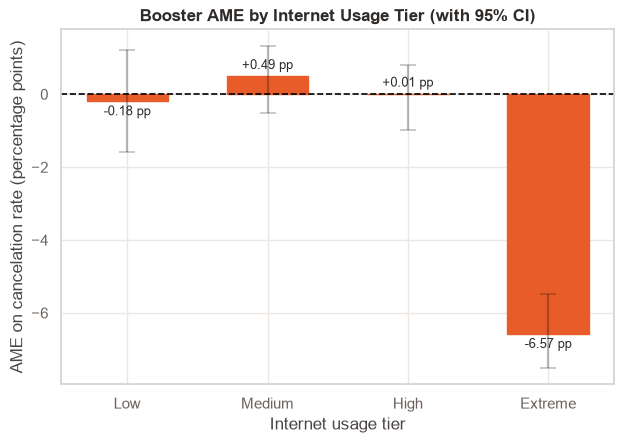

In [7]:
# Build plotting frame from the existing last-table object (tier_effects).
tier_plot = (
    tier_effects.reset_index()
    .assign(
        booster_effect_pp=lambda d: d["mean"] * 100,
        ci_low_boot_pp=lambda d: d["ci_low_boot"] * 100,
        ci_high_boot_pp=lambda d: d["ci_high_boot"] * 100,
    )
    [["internet_usage", "count", "booster_effect_pp", "ci_low_boot_pp", "ci_high_boot_pp"]]
    .copy()
)

# Keep business order on x-axis.
usage_order = ["Low", "Medium", "High", "Extreme"]
tier_plot["internet_usage"] = pd.Categorical(
    tier_plot["internet_usage"].astype(str), categories=usage_order, ordered=True
)
tier_plot = tier_plot.sort_values("internet_usage")

# Asymmetric error bars from bootstrap CI bounds.
err_low = tier_plot["booster_effect_pp"] - tier_plot["ci_low_boot_pp"]
err_high = tier_plot["ci_high_boot_pp"] - tier_plot["booster_effect_pp"]

x = np.arange(len(tier_plot))
y = tier_plot["booster_effect_pp"].to_numpy()

fig, ax = plt.subplots(figsize=(6.4, 4.6))
bars = ax.bar(
    x,
    y,
    yerr=[err_low.to_numpy(), err_high.to_numpy()],
    width=0.58,
    color=AME_PLOT_COLORS["bar_fill"],
    edgecolor=AME_PLOT_COLORS["bar_edge"],
    linewidth=1.0,
    error_kw={
        "ecolor": AME_PLOT_COLORS["ci"],
        "alpha": 0.25,
        "elinewidth": 1.6,
        "capsize": 6,
        "capthick": 1.2,
        "zorder": 1,
    },
)

# Reference line: no effect.
ax.axhline(0, color=AME_PLOT_COLORS["reference"], linestyle="--", linewidth=1.2)

# Label point estimates on top of each bar.
for i in range(len(tier_plot)):
    y_text = y[i] + (0.12 if y[i] >= 0 else -0.12)
    ax.text(
        x[i],
        y_text,
        f"{y[i]:+.2f} pp",
        ha="center",
        va="bottom" if y[i] >= 0 else "top",
        fontsize=9,
        zorder=3,
        color=AME_PLOT_COLORS["label"],
    )

ax.set_xticks(x)
ax.set_xticklabels(tier_plot["internet_usage"].astype(str))
ax.set_title("Booster AME by Internet Usage Tier (with 95% CI)", fontweight="bold")
ax.set_xlabel("Internet usage tier")
ax.set_ylabel("AME on cancelation rate (percentage points)")
plt.tight_layout()
plt.show()